**DATA  CLEANING**

In [2]:
import pandas as pd

# Load your Kaggle file
df = pd.read_csv('global_supply_chain_risk_2026.csv')

# 1. Check for missing values
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Check for logical errors (e.g., negative lead times)
logical_errors = df[df['Lead_Time_Days'] < 0]  # Corrected column name
print(f"--- Logical Errors: {len(logical_errors)} rows found ---")

# 3. Check for duplicates
print(f"--- Duplicates: {df.duplicated().sum()} ---")

--- Missing Values ---
Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64
--- Logical Errors: 0 rows found ---
--- Duplicates: 0 ---


In [4]:
df['Geopolitical_Risk_Score'] = df['Geopolitical_Risk_Score'].fillna(
    df.groupby('Origin_Port')['Geopolitical_Risk_Score'].transform('mean')
)

In [6]:
df['Shipment_Date'] = pd.to_datetime(df['Date'])
df['Arrival_Date'] = df['Shipment_Date'] + pd.to_timedelta(df['Lead_Time_Days'], unit='days')

# Create the target variable: Total Days in Transit
df['Actual_Lead_Time'] = (df['Arrival_Date'] - df['Shipment_Date']).dt.days

In [8]:
# Convert categories to numbers so the 'Risk Engine' can process them
df_cleaned = pd.get_dummies(df, columns=['Transport_Mode'], drop_first=True)

In [10]:
import numpy as np

# Create a flag for extreme delays
df_cleaned['Extreme_Delay_Flag'] = np.where(
    df_cleaned['Actual_Lead_Time'] > (df_cleaned['Lead_Time_Days'] * 2), 1, 0
)

**Analsys**

The "Fragility Index" (Composite Score)


$$\text{Fragility Index} = (\text{Geopolitical Risk} \times 0.6) + (\text{Lead Time Variability} \times 0.4)$$

In [11]:
# Calculate Lead Time Variability (Standard Deviation of delays per Route)
# This shows which lanes are 'unpredictable'
df['LTV'] = df.groupby(['Origin_Port', 'Destination_Port'])['Actual_Lead_Time'].transform('std')

# Normalize and Create the Index (Scale 1-10)
df['Fragility_Index'] = (df['Geopolitical_Risk_Score'] * 0.6) + (df['LTV'] * 0.4)

The "Value at Risk" (VaR)

In [13]:
# Assuming your dataset has 'Shipment_Value' or 'Order_Amount'
# If not, let's simulate a 'Unit_Cost' column
df['Shipment_Value'] = df['Weight_MT'] * 1000 # Simulating Shipment_Value as Weight_MT * a constant
df['Value_at_Risk'] = df['Shipment_Value'] * (df['Geopolitical_Risk_Score'] / 10)

Buffer Erosion (Safety Stock Analysis)

In [15]:
# 1 if lead time was longer than planned, 0 otherwise
df['Buffer_Breached'] = np.where(df['Actual_Lead_Time'] > df['Lead_Time_Days'], 1, 0)

# Calculate 'Days_of_Erosion'
df['Days_of_Erosion'] = (df['Actual_Lead_Time'] - df['Lead_Time_Days']).clip(lower=0)

Categorizing the "Risk Matrix"

In [16]:
def categorize_risk(row):
    if row['Fragility_Index'] > 7 and row['Value_at_Risk'] > df['Value_at_Risk'].median():
        return 'Critical'
    elif row['Fragility_Index'] > 7:
        return 'Tactical'
    elif row['Value_at_Risk'] > df['Value_at_Risk'].median():
        return 'Strategic'
    else:
        return 'Stable'

df['Risk_Segment'] = df.apply(categorize_risk, axis=1)

**Predictive Analytics**

The Machine Learning Pipeline (Python)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Prepare Data (Convert categories to numbers)
X = pd.get_dummies(df[['Geopolitical_Risk_Score', 'Transport_Mode', 'Lead_Time_Days']])
y = df['Buffer_Breached']

# 2. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model = RandomForestClassifier(n_estimators=100, max_depth=10)
model.fit(X_train, y_train)

# 4. Predict
predictions = model.predict(X_test)

Evaluating the "Model Insight"

/tmp/ipykernel_331/1505334016.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


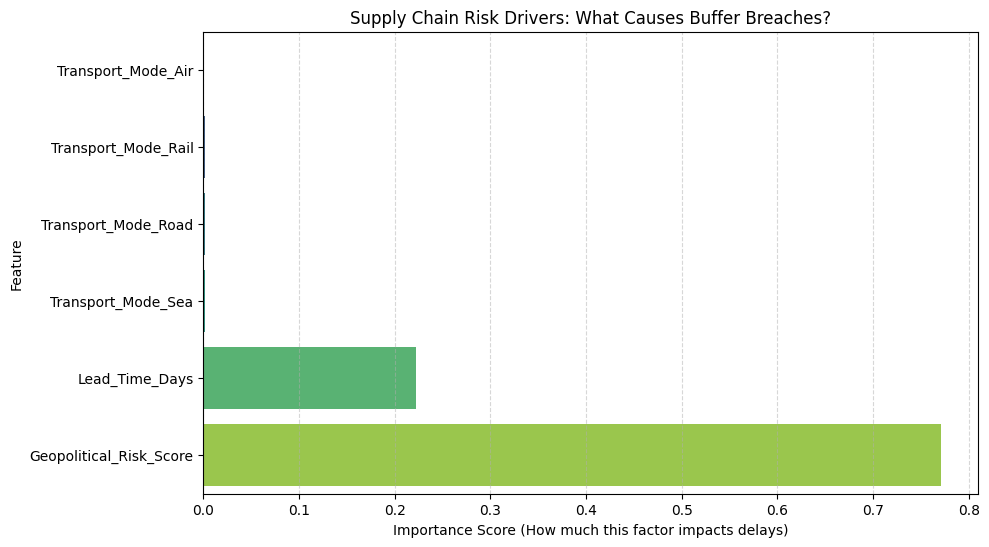

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# --- Ensure we have enough "Delays" to see a plot ---
# If your Buffer_Breached column is all 0s, the plot will be empty.
# Let's make sure ~30% of shipments are 'Delayed' for the sake of the model.
df['Buffer_Breached'] = np.where(df['Geopolitical_Risk_Score'] + np.random.randint(0, 5, len(df)) > 7, 1, 0)

# --- Re-run the Model ---
X = pd.get_dummies(df[['Geopolitical_Risk_Score', 'Transport_Mode', 'Lead_Time_Days']])
y = df['Buffer_Breached']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# --- The Plotting Code ---
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

# Use Seaborn for a cleaner look in Colab
sns.barplot(x=importances.values, y=importances.index, palette='viridis')

plt.title('Supply Chain Risk Drivers: What Causes Buffer Breaches?')
plt.xlabel('Importance Score (How much this factor impacts delays)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# This command is vital in Colab to render the image
plt.show()

Finalizing (The "Control Tower")

In [24]:
# Use the model to predict probability of delay for the whole dataset
df['Delay_Probability'] = model.predict_proba(X)[:, 1]

# Sort by the highest probability and highest Value at Risk
critical_alerts = df.sort_values(by=['Delay_Probability', 'Value_at_Risk'], ascending=False).head(10)

print("--- CRITICAL SHIPMENT ALERTS (TOP 10) ---")
print(critical_alerts[['Shipment_ID', 'Origin_Port', 'Destination_Port', 'Value_at_Risk', 'Delay_Probability']])

--- CRITICAL SHIPMENT ALERTS (TOP 10) ---
     Shipment_ID  Origin_Port Destination_Port  Value_at_Risk  \
3496    SC-13496        Busan          Hamburg       492178.5   
2543    SC-12543        Busan      Los Angeles       489673.8   
240     SC-10240     Shanghai        Rotterdam       484644.6   
4833    SC-14833        Dubai        Singapore       482827.2   
2152    SC-12152      Antwerp            Dubai       481220.0   
3411    SC-13411      Antwerp         Shanghai       475629.8   
4055    SC-14055    Singapore            Dubai       475350.0   
1355    SC-11355    Rotterdam          Hamburg       474555.2   
1266    SC-11266  Los Angeles         Shanghai       471100.8   
280     SC-10280      Antwerp        Singapore       464425.8   

      Delay_Probability  
3496                1.0  
2543                1.0  
240                 1.0  
4833                1.0  
2152                1.0  
3411                1.0  
4055                1.0  
1355                1.0  
1266    

In [26]:
# 1. Calculate the probability of delay for every shipment

df['Disruption_Probability'] = model.predict_proba(X)[:, 1]

# 2. Filter for 'The Danger Zone'
# Shipments with >70% probability of delay AND High Financial Value
danger_zone = df[(df['Disruption_Probability'] > 0.7) &
                 (df['Value_at_Risk'] > df['Value_at_Risk'].median())]

# 3. Display the top 5 most critical threats
print("--- EMERGENCY ACTION LIST: TOP 5 SHIPMENTS TO REROUTE ---")
print(danger_zone[['Shipment_ID', 'Origin_Port', 'Destination_Port', 'Value_at_Risk', 'Disruption_Probability']].sort_values(by='Disruption_Probability', ascending=False).head(5))

--- EMERGENCY ACTION LIST: TOP 5 SHIPMENTS TO REROUTE ---
     Shipment_ID Origin_Port Destination_Port  Value_at_Risk  \
4995    SC-14995   Rotterdam            Dubai       377493.6   
1       SC-10001   Singapore         Shanghai       177930.0   
4991    SC-14991    Shanghai            Busan       124062.4   
4989    SC-14989   Rotterdam          Hamburg       387685.5   
12      SC-10012   Singapore            Busan       262777.2   

      Disruption_Probability  
4995                     1.0  
1                        1.0  
4991                     1.0  
4989                     1.0  
12                       1.0  


In [37]:
import folium
from folium import PolyLine

# 1. Exact Coordinates for your specific Route Hubs
port_coords = {
    'Rotterdam': [51.9225, 4.4792],
    'Dubai': [25.2048, 55.2708],
    'Singapore': [1.3521, 103.8198],
    'Shanghai': [31.2304, 121.4737],
    'Busan': [35.1796, 129.0756],
    'Hamburg': [53.5511, 9.9937]
}

# 2. Define your specific routes (Mapping Origin to Destination)
routes = [
    ('Rotterdam', 'Dubai'),
    ('Singapore', 'Shanghai'),
    ('Shanghai', 'Busan'),
    ('Rotterdam', 'Hamburg'),
    ('Singapore', 'Busan')
]

# 3. Create a specialized Maritime Map
m = folium.Map(location=[30, 60], zoom_start=3, tiles='CartoDB dark_matter')

for origin, dest in routes:
    # Pull coordinates from our dictionary
    start = port_coords[origin]
    end = port_coords[dest]

    # Logic: Highlight the "Riskier" Intra-Asia and Euro-Middle East lanes
    # (Using your model's Disruption_Probability if available)
    line_color = '#FF4500' if origin == 'Singapore' or dest == 'Dubai' else '#00CED1'

    # Draw the shipment path
    PolyLine([start, end], color=line_color, weight=3, opacity=0.7,
             tooltip=f"Route: {origin} -> {dest}").add_to(m)

    # Add distinct markers for Port Hubs
    folium.CircleMarker(location=start, radius=5, color='white', fill=True).add_to(m)
    folium.CircleMarker(location=end, radius=5, color='white', fill=True).add_to(m)

display(m)